# The BBM-BBM system of `example6` with OpenMP

This is the problem of `example6`, a solitary wave in a channel with a cylinder, run on several threads with OpenMP.

**Building FEMd with OpenMP.** OpenMP is off by default. On macOS install the OpenMP runtime first, then build FEMd with it, from the FEMd folder:

```bash
brew install libomp                                  # macOS only, Linux compilers ship OpenMP
pip install . -C cmake.define.FEMD_OPENMP=ON
```

Restart the kernel afterwards. `fd.has_openmp()` is then `True`, and `fd.set_num_threads(k)` sets how many threads the parallel loops use. The results are the same for any number of threads, to the last digit.

**NumPy's own threads.** When FEMd uses several threads, NumPy's linear algebra library should use one, or the two compete for the cores. The first cell sets `OPENBLAS_NUM_THREADS=1` (and the same for MKL and Apple's Accelerate) before NumPy is imported, so run it first in a fresh kernel.

Without OpenMP the notebook still runs, on one thread.

In [1]:
import os
for var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(var, "1")                 # NumPy's libraries on one thread; FEMd sets its own count

import time
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import dot, grad, div, dx

print("OpenMP:", fd.has_openmp(), "  cores:", os.cpu_count(), "  loops go parallel above", fd.omp_threshold())

OpenMP: True   cores: 11   loops go parallel above 4096


The problem of `example6`: the mesh, $P_1$ for $\eta$ and $P_2$ for $u$ with $u\cdot n = 0$ on the walls, the two forms and the solitary wave.

In [2]:
b = 1 / 6
channel = [(-15, -6), (20, -6), (20, 6), (-15, 6)]
m = fd.triangulate(channel, holes=[fd.circle(4, 0, 1.0, 48)], max_edge=0.3, min_angle=28)

Q = fd.LagrangeSpace(m, 1)                          # eta, P1
V = fd.VectorFunctionSpace(m, 2, slip=[1, 2])       # u, P2, u.n = 0 on every wall
W = fd.ProductSpace(Q, V)
(e, u), (phi, psi) = fd.TrialFunctions(W), fd.TestFunctions(W)

M = fd.form((e * phi + b * dot(grad(e), grad(phi)) + dot(u, psi) + b * div(u) * div(psi)) * dx)
w = fd.Function(W)
eta, vel = w
F = fd.form((dot((1 + eta) * vel, grad(phi)) + (eta + 0.5 * dot(vel, vel)) * div(psi)) * dx)
mass = fd.form(eta * dx)
energy = fd.form(0.5 * (eta**2 + (1 + eta) * dot(vel, vel)) * dx)

A, x0 = 0.2, -5.0
eta0 = A * fd.sech(np.sqrt(3 * A) / 2 * (fd.x - x0))**2
w.project([eta0, fd.as_vector([eta0 - eta0**2 / 4, 0])])
w_start = w.vector.copy()                           # the initial state, to restart from
print(m.ntriangles, "triangles,", W.dim, "unknowns")

23635 triangles, 106600 unknowns


**Timing.** We take 20 steps of RK4 from the same initial state with 1, 2, 4, ... threads, up to the number of cores, and compare the time per step. The solutions must agree exactly.

In [3]:
dt = 0.1
rk = fd.ERK(M, F, dt, "rk4")

ncores = os.cpu_count() if fd.has_openmp() else 1
threads = sorted({k for k in (1, 2, 4, 8, 16, ncores) if k <= ncores})

per_step, result = {}, {}
for k in threads:
    fd.set_num_threads(k)
    w.vector[:] = w_start
    t0 = time.perf_counter()
    for n in range(20):
        rk.step(w)
    per_step[k] = (time.perf_counter() - t0) / 20
    result[k] = w.vector.copy()

print("threads   s/step   speedup   max difference from 1 thread")
for k in threads:
    print(f"{k:7d} {per_step[k]:8.3f} {per_step[1] / per_step[k]:9.2f}   {np.max(np.abs(result[k] - result[1])):.1e}")

threads   s/step   speedup   max difference from 1 thread
      1    0.131      1.00   0.0e+00
      2    0.106      1.23   0.0e+00
      4    0.097      1.35   0.0e+00
      8    0.103      1.27   0.0e+00
     11    0.097      1.35   0.0e+00


**What runs in parallel.** The assembly of `F` at each stage, the evaluation of the fields at the quadrature points, and the matrix-vector products run on all threads. The solves with the sparse Cholesky factor of $M$, and the arithmetic of the integrand, which FEMd does with NumPy, run on one thread. Here they take more than half of each step, so the speedup stays well below the number of threads.

**The full run.** Now the whole computation of `example6`, up to $T = 40$, with every core.

400 steps on 11 thread(s) in 37.9 s
change in mass:            8.881784197001252e-15
relative change in energy: 2.6706030178395546e-06


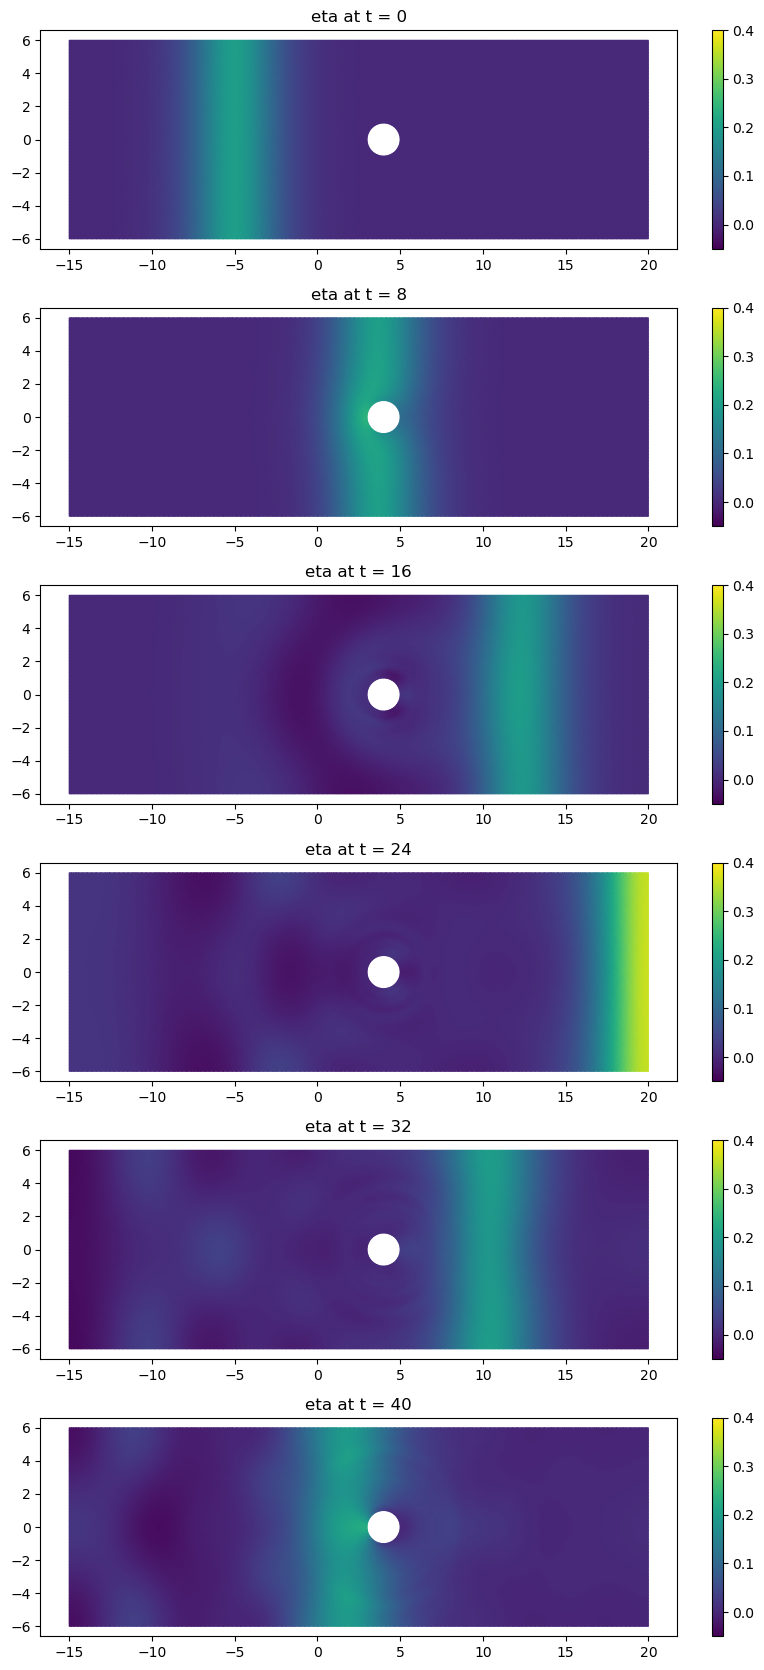

In [4]:
fd.set_num_threads(ncores)
w.vector[:] = w_start
rk = fd.ERK(M, F, dt, "rk4")
mass0, E0 = mass.assemble(), energy.assemble()

T = 40.0
eh = w.split()[0]
snapshots = {0.0: eh.vector.copy()}
t0 = time.perf_counter()
for n in range(1, int(round(T / dt)) + 1):
    rk.step(w)
    if n % 80 == 0:
        snapshots[round(rk.t, 6)] = w.split()[0].vector.copy()
print(f"{int(round(T / dt))} steps on {ncores} thread(s) in {time.perf_counter() - t0:.1f} s")
print("change in mass:           ", abs(mass.assemble() - mass0))
print("relative change in energy:", abs(energy.assemble() - E0) / E0)

fig, axs = plt.subplots(len(snapshots), 1, figsize=(9, 2.8 * len(snapshots)))
for ax, (t, coeffs) in zip(axs, snapshots.items()):
    fd.Function(Q, "eta", coeffs).plot(ax, cmap="viridis", vmin=-0.05, vmax=0.4)
    ax.set_title(f"eta at t = {t:g}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()